# Jupyter Notebook
## Lec 13 - $K$-Fold CV 


In [21]:
# Everyone's favorite standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

Let's bring back the data set from last time!

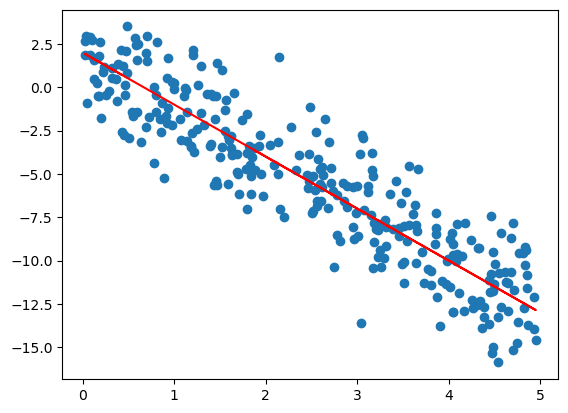

In [22]:
# Set the seed so everyone has the same numbers
np.random.seed(42)

def f(t, m = -3, b = 2):
    return m*t+b

n = 300
X_toy = np.random.uniform(0,5,n)
y_toy = f(X_toy) + np.random.normal(0,2,n)

X_toy = X_toy.reshape(-1,1)
y_toy = y_toy.reshape(-1,1)

plt.scatter(X_toy,y_toy)
plt.plot(X_toy,f(X_toy),c = 'red')

# 1. Roll your own $k$-fold

Ok, let's try to get a handle on what this $k$-fold CV is doing with our data. To do that, we're going to build our own $k$-fold splitter before we use the provided tools in `scikitlearn`. Of course, this is not going to be optimized at all, the goal is just to figure out how the innards are working. 

&#9989; **<font color=red>Do this:</font>** For our first example, let's say you have 12 data points and you want $k=4$ folds. How many data points will be in each fold?


*your answer here*

&#9989; **<font color=red>Do this:</font>** Below is the skeleton of code that will return the $k$-fold train/test splits. Update the code where noted to make it work. 

How do you check that your code is doing what you want? 
- Make sure you end up with $k$ splits 
- Make sure that each of the testing splits has $n/k$ data points
- Make sure that the rest of the data points end up in the training set. 
- A good check is to see that you have all $n$ data points between the training and testing set every time.

In [24]:
def mykfold(n,k):
    # Input: integers n and k.
    #        This version is only going to allow us to work with  
    #        a $k$ that is actually divisible by $n$ 
    # Output: a list of the train/test splits to be used.
    
    # This command is just going to make a warning so that if you pass in 
    # n and k not divisble, the code will kick you out.     
    assert (n % k == 0), "k doesn't divide n, this code can't handle it"
    
    # Make an array of the indices:
    all_my_indices = np.array(range(n))
    
    
    # First, shuffle your array to make sure we're working with randomized order.
    # ----your code here to shuffle----# 
    
    
    # Write an equation that will figure out the length of each fold below
    length_of_fold = np.nan #<----- fix this
    
    
    # Now we're going to keep a list of all your splits. Modify the code below so that 
    # you can keep track of the training and testing splits.
    AllSplits = []
    for i in range(k):
        
        test_set = [] #<------ fix this
        training_set = [] #<------ fix this, too
        AllSplits.append({'train': training_set, 'test':test_set})
    
    return AllSplits
 
n = 12
k = 4
mykfold(n,k)
    

[{'train': [], 'test': []},
 {'train': [], 'test': []},
 {'train': [], 'test': []},
 {'train': [], 'test': []}]

Ok, so now your code returns indicies kind of like the LOOCV code from last time. 

&#9989; **<font color=red>Do this:</font>** Set up a linear regression model for the toy data above, and use your train test split code to figure out the MSE for each, then return the average for your $CV_{(4)}$ score, where this means we want $k=4$ folds.

In [26]:
n = X_toy.shape[0]
k = 3

mySplits = mykfold(n,k)

MSE = []
for entry in mySplits:
    train_index = entry['train']
    test_index = entry['test']
    # print("TRAIN:", train_index, "\nTEST:", test_index, '\n')

    #Your code here!
    
print(np.average(MSE))

nan


/Users/bao/anaconda3/lib/python3.11/site-packages/numpy/lib/function_base.py:518: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/Users/bao/anaconda3/lib/python3.11/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


# 2. Letting scikitlearn do the work for us. 

Ok, now that we understand the innards, we can let `scikitlearn` do this for us.

In [28]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=3)

# Notice that like the leave one out version, trying to print kf still doesn't give us much that's useful
print(kf)

KFold(n_splits=3, random_state=None, shuffle=False)


We can see the splits by putting this generator into a for loop as follows. Note I'm using the tiny version of the data set for this just so the pattern is easier to see. 

In [29]:
X_tiny_toy = X_toy[:10]
y_tiny_toy = y_toy[:10]

In [30]:
for train_index, test_index in kf.split(X_tiny_toy):
    print("TRAIN:", train_index, "\nTEST:", test_index, '\n')
    X_train, X_test = X_tiny_toy[train_index], X_tiny_toy[test_index]
    y_train, y_test = y_tiny_toy[train_index], y_tiny_toy[test_index]

TRAIN: [4 5 6 7 8 9] 
TEST: [0 1 2 3] 

TRAIN: [0 1 2 3 7 8 9] 
TEST: [4 5 6] 

TRAIN: [0 1 2 3 4 5 6] 
TEST: [7 8 9] 



There is a BIG PROBLEM with using this code.  We haven't done something!!! Something important!!!

&#9989; **<font color=red>Q:</font>** What didn't we do? This is an easy fix, checkout the [documentation for `KFold`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.KFold.html), then modify the code below to fix the problem. 



In [31]:
# Fix this code! 
kf = KFold(n_splits=3)

for train_index, test_index in kf.split(X_tiny_toy):
    print("TRAIN:", train_index, "\nTEST:", test_index, '\n')
    X_train, X_test = X_tiny_toy[train_index], X_tiny_toy[test_index]
    y_train, y_test = y_tiny_toy[train_index], y_tiny_toy[test_index]

TRAIN: [4 5 6 7 8 9] 
TEST: [0 1 2 3] 

TRAIN: [0 1 2 3 7 8 9] 
TEST: [4 5 6] 

TRAIN: [0 1 2 3 4 5 6] 
TEST: [7 8 9] 



Now that we have our train/test split generator set up, let's take a look at the result. Note that this is just going to color by the last split generated in that for loop up above. 

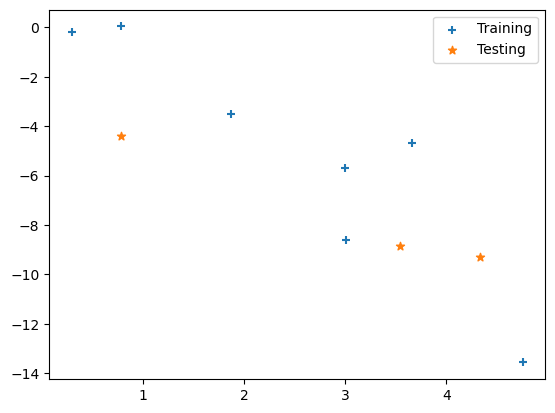

In [33]:
plt.scatter(X_train,y_train, marker = '+', label = "Training")
plt.scatter(X_test,y_test, marker = '*', label = "Testing")
plt.legend()

&#9989; **<font color=red>Q:</font>** Below is my code from last class to train our linear regression model, again just using that last train/test split. Fix this so that:
- it uses the full `X_toy`, `y_toy` data set (rather than the tiny version)
- it uses every k-fold train/test split ($k=5$) with the shuffle built in, and 
- returns the average of the MSEs. 


In [17]:
# Your code goes here

model = LinearRegression()
model.fit(X_train,y_train)
y_hat = model.predict(X_test.reshape(-1,1))

mean_squared_error(y_hat,y_test)

5.428051755710641

&#9989; **<font color=red>Q:</font>** What happens if you set `n_splits` to be the same as the number of data points? 

*Your answer here*

##ANSWER## 
This is LOOCV again. 

### Easy mode

As before, we can build all this work into a very compact code, which really is doing the same thing, just in a few lines. 

In [19]:
# This command does all your work for you
# Note this is the same command you used Monday for LOOCV
from sklearn.model_selection import cross_val_score

# Set up linear regression model
model = LinearRegression()

# Pick your CV method
kf = KFold(n_splits=5, shuffle = True)

#use 5-fold CV to evaluate model
scores = cross_val_score(model, X_toy, y_toy, 
                         scoring='neg_mean_squared_error',
                         cv=kf)

# View mean absolute error
np.average(np.absolute(scores))



3.8976222566077583

&#9989; **<font color=red>Q:</font>**
- How do you change the above code to do $k$-fold CV for a different $k$?
- You didn't get exactly the same value as you computed a few cells up. Why?

In [20]:
##Your answer here###



-----
### Congratulations, we're done!
Written by Dr. Liz Munch, modified by Dr. Lianzhang Bao and Dr. Firas Khasawneh, Michigan State University

<a rel="license" href="http://creativecommons.org/licenses/by-nc/4.0/"><img alt="Creative Commons License" style="border-width:0" src="https://i.creativecommons.org/l/by-nc/4.0/88x31.png" /></a><br />This work is licensed under a <a rel="license" href="http://creativecommons.org/licenses/by-nc/4.0/">Creative Commons Attribution-NonCommercial 4.0 International License</a>.